# MODELAMIENTO CON UN DT DE AUDIO

librerias

In [1]:
# Manejo de directorios y rutas
import os

# Computación numérica y manejo de matrices
import numpy as np

# Manejo y preprocesamiento de datos
import pandas as pd

# Librerías para graficación
from matplotlib import pyplot

# Mostrar gráficos dentro del cuadernillo
%matplotlib inline
import matplotlib.pyplot as plt

import random

import librosa

In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("CUDA de PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

#si queremos mejorar este codigo deberiamos de usar el siguiente para que se use cuda siempre y cuando existan esos nuvles y si no permanecer en cpu
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#print(f'Dispositivo en uso: {device}')
#print(f'Versión de PyTorch: {torch.__version__}')

PyTorch: 2.13.0+cu132
CUDA disponible: True
CUDA de PyTorch: 13.2
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


## cargamos el csv

In [3]:
metadata_us8k = pd.read_csv("dt_au/urbansound8k/UrbanSound8K.csv")
print(metadata_us8k.shape)
metadata_us8k.head()

(8732, 8)


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [4]:
print(metadata_us8k["class"].value_counts())

class
dog_bark            1000
children_playing    1000
air_conditioner     1000
street_music        1000
engine_idling       1000
jackhammer          1000
drilling            1000
siren                929
car_horn             429
gun_shot             374
Name: count, dtype: int64


In [5]:
def extraer_features(path_archivo):
    y, sr = librosa.load(path_archivo)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    mfccs_mean = np.mean(mfccs.T, axis=0)
    return mfccs_mean

In [6]:
features_us8k = []
audio_path_us8k = "dt_au/urbansound8k" 

for index, row in metadata_us8k.iterrows():
    fold_us8k = f"fold{row['fold']}"
    file_path_us8k = os.path.join(audio_path_us8k, fold_us8k, row["slice_file_name"])

    try:
        mfccs_us8k = extraer_features(file_path_us8k)
        features_us8k.append([mfccs_us8k, row["classID"], row["fold"]])
    except Exception as e:
        print(f"Error en {file_path_us8k}: {e}")

    if not (index + 1) % 500:
        print(f"Procesados {index + 1}/{len(metadata_us8k)}")

print("Extracción completa")

Procesados 500/8732
Procesados 1000/8732
Procesados 1500/8732
Procesados 2000/8732
Procesados 2500/8732
Procesados 3000/8732
Procesados 3500/8732


c:\Users\USUARIO\Desktop\ia_davalos\practicas\.venv\Lib\site-packages\librosa\core\spectrum.py:3004: UserWarning: n_fft=2048 is too large for input signal of length=1323
  stft(


Procesados 4000/8732
Procesados 4500/8732
Procesados 5000/8732
Procesados 5500/8732
Procesados 6000/8732
Procesados 6500/8732
Procesados 7000/8732
Procesados 7500/8732
Procesados 8000/8732


c:\Users\USUARIO\Desktop\ia_davalos\practicas\.venv\Lib\site-packages\librosa\core\spectrum.py:3004: UserWarning: n_fft=2048 is too large for input signal of length=1103
  stft(
c:\Users\USUARIO\Desktop\ia_davalos\practicas\.venv\Lib\site-packages\librosa\core\spectrum.py:3004: UserWarning: n_fft=2048 is too large for input signal of length=1523
  stft(


Procesados 8500/8732
Extracción completa


In [7]:
print(len(features_us8k))
print(len(metadata_us8k))

8732
8732


In [ ]:
features_df_us8k = pd.DataFrame(features_us8k, columns=["feature", "classID", "fold"])
features_df_us8k.to_pickle("features_us8k.pkl")
features_df_us8k.head()

,feature,classID,fold
0,"[-211.93698, 62.581207, -122.81315, -60.745293...",3,5
1,"[-417.0052, 99.336624, -42.995586, 51.073326, ...",2,5
2,"[-452.39316, 112.36253, -37.57807, 43.195866, ...",2,5
3,"[-406.47922, 91.1966, -25.043556, 42.78452, 11...",2,5
4,"[-439.63867, 103.86224, -42.658783, 50.690277,...",2,5


creacion de variables

In [9]:
X_us8k = np.array(features_df_us8k["feature"].tolist())
y_us8k = np.array(features_df_us8k["classID"].tolist())
fold_us8k = np.array(features_df_us8k["fold"].tolist())

print("X shape:", X_us8k.shape)
print("y shape:", y_us8k.shape)

X shape: (8732, 40)
y shape: (8732,)


In [10]:
from sklearn.model_selection import train_test_split

X_train_us8k, X_test_us8k, y_train_us8k, y_test_us8k = train_test_split(
    X_us8k, y_us8k,
    test_size=0.20,
    random_state=42,
    stratify=y_us8k
)

In [11]:
def featureNormalize(X):

    X_norm = X.copy()

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [12]:
X_train_us8k, mu, sigma = featureNormalize(X_train_us8k)

X_test_us8k = (X_test_us8k - mu) / sigma

In [13]:
import torch

X_train_us8k_t = torch.tensor(
    X_train_us8k,
    dtype=torch.float32
).cuda()

X_test_us8k_t = torch.tensor(
    X_test_us8k,
    dtype=torch.float32
).cuda()

y_train_us8k_t = torch.tensor(
    y_train_us8k,
    dtype=torch.long
).cuda()

y_test_us8k_t = torch.tensor(
    y_test_us8k,
    dtype=torch.long
).cuda()

In [19]:
D_in, H1,H2,  D_out = 40, 150, 100, 10
model = torch.nn.Sequential(
torch.nn.Linear(D_in, H1),
torch.nn.ReLU(),
torch.nn.Dropout(0.2),
torch.nn.Linear(H1, H2),
torch.nn.ReLU(),
torch.nn.Dropout(0.2),
torch.nn.Linear(H2, D_out),
).cuda()

criterion = torch.nn.CrossEntropyLoss()


optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epochs = 12000
log_each = 10

l = []
val_l = []         

best_val_loss = float("inf")
patience = 500                 
step = 0                       

model.train()

for e in range(1, epochs + 1):

    model.train()             

    
    y_pred = model(X_train_us8k_t)

   
    loss_emnist = criterion(
        y_pred,
        y_train_us8k_t
    )

    l.append(loss_emnist.item())

    
    optimizer.zero_grad()

    
    loss_emnist.backward()


    optimizer.step()

   
    model.eval()
    with torch.no_grad():
        val_logits_emnist = model(X_test_us8k_t)
        val_loss_emnist = criterion(
            val_logits_emnist,
            y_test_us8k_t
        )
    val_l.append(val_loss_emnist.item())

    if val_loss_emnist.item() < best_val_loss:
        best_val_loss = val_loss_emnist.item()
        torch.save(model.state_dict(), "ckpt_exa_us8k.pt")
        step = 0
    else:
        step += 1

    if step > patience:
        print(f"Early stopping en epoch {e} (sin mejora en {patience} epochs)")
        break
    

    if not e % log_each:
        print(
            f"Epoch {e}/{epochs} "
            f"Loss {loss_emnist.item():.5f} "
            f"Val_loss {val_loss_emnist.item():.5f}" 
        )

model.load_state_dict(torch.load("ckpt_exa_us8k.pt"))

Epoch 10/12000 Loss 2.30079 Val_loss 2.29683
Epoch 20/12000 Loss 2.27912 Val_loss 2.27764
Epoch 30/12000 Loss 2.25942 Val_loss 2.25872
Epoch 40/12000 Loss 2.24001 Val_loss 2.23943
Epoch 50/12000 Loss 2.22072 Val_loss 2.21926
Epoch 60/12000 Loss 2.19817 Val_loss 2.19785
Epoch 70/12000 Loss 2.17589 Val_loss 2.17484
Epoch 80/12000 Loss 2.15165 Val_loss 2.15027
Epoch 90/12000 Loss 2.12517 Val_loss 2.12409
Epoch 100/12000 Loss 2.09822 Val_loss 2.09662
Epoch 110/12000 Loss 2.06848 Val_loss 2.06788
Epoch 120/12000 Loss 2.03998 Val_loss 2.03799
Epoch 130/12000 Loss 2.01189 Val_loss 2.00724
Epoch 140/12000 Loss 1.97699 Val_loss 1.97578
Epoch 150/12000 Loss 1.94615 Val_loss 1.94372
Epoch 160/12000 Loss 1.91533 Val_loss 1.91124
Epoch 170/12000 Loss 1.88235 Val_loss 1.87844
Epoch 180/12000 Loss 1.84766 Val_loss 1.84550
Epoch 190/12000 Loss 1.81268 Val_loss 1.81260
Epoch 200/12000 Loss 1.78108 Val_loss 1.77995
Epoch 210/12000 Loss 1.75253 Val_loss 1.74786
Epoch 220/12000 Loss 1.71861 Val_loss 1.716

<All keys matched successfully>

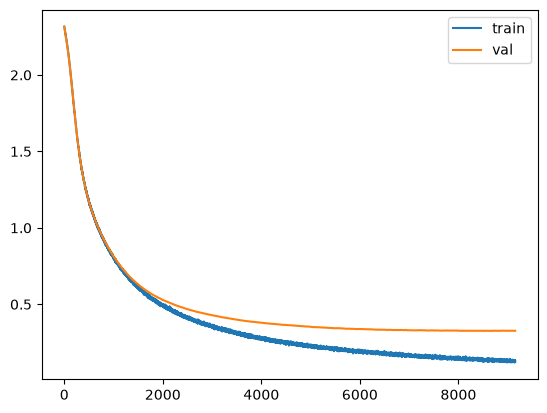

In [20]:
plt.plot(l, label="train")
plt.plot(val_l, label="val")
plt.legend()

In [21]:
from sklearn.metrics import accuracy_score

def evaluate(x):

    model.eval()

    logits = model(x)

    probabilidades = torch.softmax(logits, dim=1)

    predicciones = torch.argmax(
        probabilidades,
        dim=1
    )

    return predicciones

In [22]:
y_pred = evaluate(
    X_test_us8k_t
)

accuracy = accuracy_score(
    y_test_us8k_t.cpu().numpy(),
    y_pred.cpu().numpy()
)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 90.67%


## METRICAS

matriz de confucion

In [23]:
from sklearn.metrics import confusion_matrix

cm_emnist = confusion_matrix(
    y_test_us8k_t.cpu().numpy(),
    y_pred.cpu().numpy()
)

print(cm_emnist)

[[194   0   1   0   1   1   0   0   0   3]
 [  1  77   0   0   1   1   0   3   0   3]
 [  4   0 171   5   4   0   3   0   3  10]
 [  1   0   8 172   4   5   1   0   4   5]
 [  0   0   1   3 182   0   0   7   0   7]
 [  1   0   0   1   0 194   0   0   2   2]
 [  0   0   7   7   1   0  58   0   0   2]
 [  0   0   0   1   9   0   0 185   0   5]
 [  1   0   5   3   0   0   0   0 175   2]
 [  1   1   9   4   2   2   0   4   1 176]]


precicion y recall

In [24]:
from sklearn.metrics import precision_score, recall_score

precision_emnist = precision_score(
    y_test_us8k_t.cpu().numpy(),
    y_pred.cpu().numpy(),
    average="macro"
)
recall_emnist = recall_score(
    y_test_us8k_t.cpu().numpy(),
    y_pred.cpu().numpy(),
    average="macro"
)

precision_emnist, recall_emnist

(0.9144434782341687, 0.89795423855964)

f1_score

In [25]:
from sklearn.metrics import f1_score

f1_emnist = f1_score(
    y_test_us8k_t.cpu().numpy(),
    y_pred.cpu().numpy(),
    average="macro"
)

f1_emnist

0.9050628560958408

CURVA ROCK

In [26]:
from sklearn.metrics import roc_auc_score

model.eval()
with torch.no_grad():
    logits_emnist = model(X_test_us8k_t)
    probabilidades_emnist = torch.softmax(logits_emnist, dim=1)

auc_emnist = roc_auc_score(
    y_test_us8k_t.cpu().numpy(),
    probabilidades_emnist.cpu().numpy(),
    multi_class="ovr",
    average="macro"
)

auc_emnist

0.9922114366358828

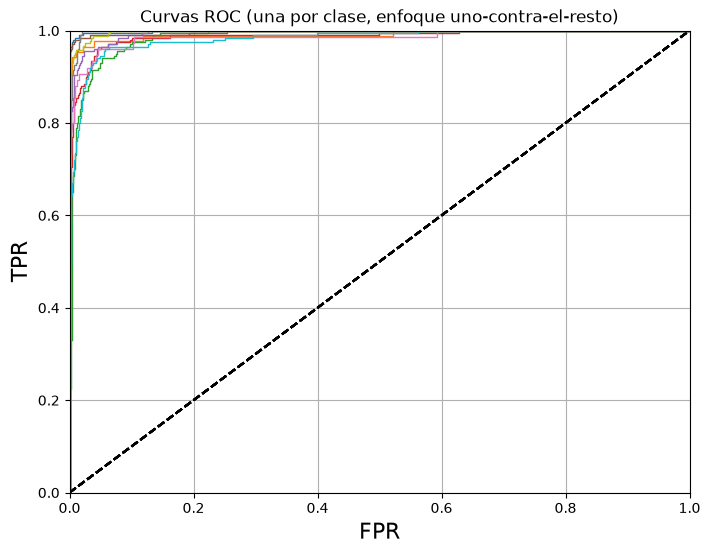

In [27]:
from sklearn.metrics import roc_curve
from sklearn.preprocessing import label_binarize
import numpy as np


y_test_bin_emnist = label_binarize(
    y_test_us8k_t.cpu().numpy(),
    classes=np.arange(D_out)
)


def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=1, label=label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('FPR', fontsize=16)
    plt.ylabel('TPR', fontsize=16)
    plt.grid(True)

plt.figure(figsize=(8, 6))


for clase in range(D_out):
    fpr, tpr, _ = roc_curve(
        y_test_bin_emnist[:, clase],
        probabilidades_emnist.cpu().numpy()[:, clase]
    )
    plot_roc_curve(fpr, tpr)

plt.title("Curvas ROC (una por clase, enfoque uno-contra-el-resto)")
plt.show()